# Track1 Encoder: DeBERTa-v2-XXLarge + LoRA + MoCo-SCL

This notebook trains a 19-class value classifier with `microsoft/deberta-v2-xxlarge`, weighted cross entropy, and a supervised MoCo-style contrastive queue. The query encoder is trained with LoRA; the key encoder is an EMA copy used only for queue features.


In [1]:
!nvidia-smi


Fri Jun 12 12:11:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0 Off |                  N/A |
| 60%   57C    P0            128W /  350W |       1MiB /  24576MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))


HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [3]:
import os

MODEL_NAME = "microsoft/deberta-v2-xxlarge"
DATA_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl"
LOGGING_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/logs/deberta_v2_xxlarge_moco_scl"
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_macro_f1_model")

MAX_LENGTH = 512
NUM_EPOCHS = 20
LR = 3e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 20
SEED = 3407

# Start high on 24GB cards; auto_find_batch_size will halve this on CUDA OOM if your Transformers supports it.
TRAIN_BATCH_SIZE = 64
EVAL_BATCH_SIZE = 64
GRADIENT_ACCUMULATION_STEPS = 1
AUTO_FIND_BATCH_SIZE = True

# LoRA keeps xxlarge trainable on a single 24GB GPU.
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["query_proj", "key_proj", "value_proj", "dense"]

# MoCo-SCL settings. Queue memory is tiny: 8192 x 256 float32 is about 8 MB.
USE_MOCO_SCL = True
SCL_ALPHA = 0.05
SCL_TEMPERATURE = 0.07
PROJECTION_DIM = 256
MOCO_QUEUE_SIZE = 8192
MOCO_MOMENTUM = 0.999

TRAIN_CONTEXT_MODE = "response_only"
EVAL_CONTEXT_MODE = "response_only"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

print(f"Model : {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")
print(f"Best model: {BEST_MODEL_DIR}")
print(f"Train batch size: {TRAIN_BATCH_SIZE}")
print(f"Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size: {TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"LoRA r/alpha: {LORA_R}/{LORA_ALPHA}")
print(f"MoCo queue: {MOCO_QUEUE_SIZE}, momentum: {MOCO_MOMENTUM}, SCL alpha: {SCL_ALPHA}")


Model : microsoft/deberta-v2-xxlarge
Output: /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl
Best model: /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
Train batch size: 64
Gradient accumulation steps: 1
Effective batch size: 64
LoRA r/alpha: 32/64
MoCo queue: 8192, momentum: 0.999, SCL alpha: 0.05


In [4]:
import json
from collections import Counter

VALUE_LABELS = [
    "Self-direction–thought",
    "Self-direction–action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power–dominance",
    "Power–resources",
    "Face",
    "Security–personal",
    "Security–societal",
    "Tradition",
    "Conformity–rules",
    "Conformity–interpersonal",
    "Humility",
    "Benevolence–dependability",
    "Benevolence–caring",
    "Universalism–concern",
    "Universalism–nature",
    "Universalism–tolerance",
]

NUM_CLASSES = len(VALUE_LABELS)
label2id = {v: i for i, v in enumerate(VALUE_LABELS)}
id2label = {i: v for i, v in enumerate(VALUE_LABELS)}

print(f"Number of classes: {NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
    for line in f:
        train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("\nTrain class distribution:")
for label in VALUE_LABELS:
    print(f"  {label:<40s}: {counter[label]}")


Number of classes: 19

Train class distribution:
  Self-direction–thought                  : 119
  Self-direction–action                   : 124
  Stimulation                             : 400
  Hedonism                                : 164
  Achievement                             : 174
  Power–dominance                         : 156
  Power–resources                         : 237
  Face                                    : 258
  Security–personal                       : 202
  Security–societal                       : 70
  Tradition                               : 90
  Conformity–rules                        : 385
  Conformity–interpersonal                : 236
  Humility                                : 100
  Benevolence–dependability               : 189
  Benevolence–caring                      : 317
  Universalism–concern                    : 160
  Universalism–nature                     : 71
  Universalism–tolerance                  : 68


In [5]:
import json
import numpy as np
from datasets import Dataset


def build_text(row, context_mode="response_only"):
    response = str(row.get("Consistent Value Response", "")).strip()
    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "full_context":
        parts = []
        if row.get("Scenario"):
            parts.append("Scenario: " + str(row.get("Scenario")).strip())
        if row.get("Question"):
            parts.append("Question: " + str(row.get("Question")).strip())
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    raise ValueError(f"Unknown context_mode: {context_mode}")


def load_jsonl(path, has_label=True, context_mode="response_only"):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})


train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=TRAIN_CONTEXT_MODE)
dev_dataset = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")


Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [6]:
import torch


def print_gpu_memory(stage):
    if not torch.cuda.is_available():
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**3
    print(
        f"[{stage}] allocated={allocated:.2f} GB | reserved={reserved:.2f} GB | "
        f"peak_allocated={peak_allocated:.2f} GB | peak_reserved={peak_reserved:.2f} GB"
    )


if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print_gpu_memory("notebook start")


[notebook start] allocated=0.00 GB | reserved=0.00 GB | peak_allocated=0.00 GB | peak_reserved=0.00 GB


In [7]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModel, AutoTokenizer, AutoConfig, DataCollatorWithPadding
from transformers.modeling_outputs import SequenceClassifierOutput
from peft import LoraConfig, TaskType, get_peft_model

train_labels_np = np.array(train_dataset["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_np,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", np.round(class_weights, 3))


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


class ProjectionHead(nn.Module):
    def __init__(self, hidden_size, projection_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, projection_dim),
        )

    def forward(self, x):
        return self.net(x)


class DebertaMoCoSCLClassifier(nn.Module):
    def __init__(self, model_name, num_labels, class_weights):
        super().__init__()
        self.num_labels = num_labels
        self.scl_alpha = SCL_ALPHA
        self.temperature = SCL_TEMPERATURE
        self.moco_momentum = MOCO_MOMENTUM
        self.use_moco_scl = USE_MOCO_SCL

        if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
            dtype = torch.bfloat16
        elif torch.cuda.is_available():
            dtype = torch.float16
        else:
            dtype = torch.float32
        self.config = AutoConfig.from_pretrained(
            model_name,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
        )
        self.query_encoder = AutoModel.from_pretrained(
            model_name,
            config=self.config,
            torch_dtype=dtype,
        )

        lora_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=LORA_TARGET_MODULES,
            bias="none",
        )
        self.query_encoder = get_peft_model(self.query_encoder, lora_config)
        if hasattr(self.query_encoder, "gradient_checkpointing_enable"):
            self.query_encoder.gradient_checkpointing_enable()
        if hasattr(self.query_encoder, "enable_input_require_grads"):
            self.query_encoder.enable_input_require_grads()

        hidden_size = self.config.hidden_size
        self.dropout = nn.Dropout(getattr(self.config, "hidden_dropout_prob", 0.1))
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.query_projector = ProjectionHead(hidden_size, PROJECTION_DIM)

        self.key_encoder = AutoModel.from_pretrained(
            model_name,
            config=self.config,
            torch_dtype=dtype,
        )
        self.key_encoder = get_peft_model(self.key_encoder, copy.deepcopy(lora_config))
        self.key_projector = ProjectionHead(hidden_size, PROJECTION_DIM)
        self._copy_query_to_key()
        self._set_key_requires_grad(False)

        self.register_buffer("class_weights", class_weights.clone().float())
        self.register_buffer("queue", F.normalize(torch.randn(MOCO_QUEUE_SIZE, PROJECTION_DIM), dim=1))
        self.register_buffer("queue_labels", torch.full((MOCO_QUEUE_SIZE,), -1, dtype=torch.long))
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    def _copy_query_to_key(self):
        self.key_encoder.load_state_dict(self.query_encoder.state_dict(), strict=False)
        self.key_projector.load_state_dict(self.query_projector.state_dict(), strict=True)

    def _set_key_requires_grad(self, requires_grad):
        for param in self.key_encoder.parameters():
            param.requires_grad = requires_grad
        for param in self.key_projector.parameters():
            param.requires_grad = requires_grad

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for q_param, k_param in zip(self.query_encoder.parameters(), self.key_encoder.parameters()):
            k_param.data.mul_(self.moco_momentum).add_(q_param.data, alpha=1.0 - self.moco_momentum)
        for q_param, k_param in zip(self.query_projector.parameters(), self.key_projector.parameters()):
            k_param.data.mul_(self.moco_momentum).add_(q_param.data, alpha=1.0 - self.moco_momentum)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys, labels):
        keys = keys.detach().float()
        labels = labels.detach().long()
        batch_size = keys.shape[0]

        if batch_size >= MOCO_QUEUE_SIZE:
            self.queue.copy_(keys[-MOCO_QUEUE_SIZE:])
            self.queue_labels.copy_(labels[-MOCO_QUEUE_SIZE:])
            self.queue_ptr[0] = 0
            return

        ptr = int(self.queue_ptr.item())
        end = ptr + batch_size
        if end <= MOCO_QUEUE_SIZE:
            self.queue[ptr:end] = keys
            self.queue_labels[ptr:end] = labels
        else:
            first = MOCO_QUEUE_SIZE - ptr
            self.queue[ptr:] = keys[:first]
            self.queue_labels[ptr:] = labels[:first]
            self.queue[:end % MOCO_QUEUE_SIZE] = keys[first:]
            self.queue_labels[:end % MOCO_QUEUE_SIZE] = labels[first:]
        self.queue_ptr[0] = end % MOCO_QUEUE_SIZE

    def _moco_supcon_loss(self, query_z, key_z, labels):
        query_z = F.normalize(query_z.float(), dim=1)
        key_z = F.normalize(key_z.float(), dim=1)
        labels = labels.long()

        valid_queue = self.queue_labels >= 0
        if valid_queue.any():
            contrast_z = torch.cat([key_z, self.queue[valid_queue].to(query_z.device)], dim=0)
            contrast_labels = torch.cat([labels, self.queue_labels[valid_queue].to(labels.device)], dim=0)
        else:
            contrast_z = key_z
            contrast_labels = labels

        logits = torch.matmul(query_z, contrast_z.T) / self.temperature
        logits = logits - logits.max(dim=1, keepdim=True).values.detach()
        pos_mask = labels.view(-1, 1).eq(contrast_labels.view(1, -1)).float()

        exp_logits = torch.exp(logits)
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True).clamp(min=1e-12))
        positive_counts = pos_mask.sum(dim=1).clamp(min=1.0)
        loss = -(pos_mask * log_prob).sum(dim=1) / positive_counts
        return loss.mean()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        encoder_kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            encoder_kwargs["token_type_ids"] = token_type_ids

        outputs = self.query_encoder(**encoder_kwargs)
        pooled = mean_pooling(outputs.last_hidden_state, attention_mask)
        logits = self.classifier(self.dropout(pooled))

        loss = None
        if labels is not None:
            ce_loss = F.cross_entropy(logits.float(), labels.view(-1), weight=self.class_weights.to(logits.device))
            loss = ce_loss

            if self.training and self.use_moco_scl and self.scl_alpha > 0:
                query_z = self.query_projector(pooled)
                with torch.no_grad():
                    self._momentum_update_key_encoder()
                    self.key_encoder.eval()
                    key_outputs = self.key_encoder(**encoder_kwargs)
                    key_pooled = mean_pooling(key_outputs.last_hidden_state, attention_mask)
                    key_z = self.key_projector(key_pooled)
                    key_z = F.normalize(key_z.float(), dim=1)

                scl_loss = self._moco_supcon_loss(query_z, key_z, labels)
                loss = ce_loss + self.scl_alpha * scl_loss
                self._dequeue_and_enqueue(key_z, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=None,
            attentions=None,
        )


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)


train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = DebertaMoCoSCLClassifier(MODEL_NAME, NUM_CLASSES, class_weights_tensor)
model.query_encoder.print_trainable_parameters()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters, including EMA key encoder: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.4f}%)")
print_gpu_memory("after model build")


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Class weights: [1.557 1.494 0.463 1.13  1.065 1.188 0.782 0.718 0.917 2.647 2.058 0.481
 0.785 1.853 0.98  0.584 1.158 2.609 2.724]


Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/778 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v2-xxlarge
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/778 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v2-xxlarge
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 42,467,328 || all params: 1,607,016,960 || trainable%: 2.6426
Total parameters, including EMA key encoder: 3,219,571,731
Trainable parameters: 45,250,835 (1.4055%)
[after model build] allocated=0.00 GB | reserved=0.00 GB | peak_allocated=0.00 GB | peak_reserved=0.00 GB


In [8]:
import inspect
import json
import os
import shutil
import evaluate
import numpy as np
from safetensors.torch import load_file as load_safetensors
from transformers import TrainingArguments, Trainer, TrainerCallback
from peft import set_peft_model_state_dict

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}


def _unwrap_model(model):
    return model.module if hasattr(model, "module") else model


def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def save_compact_query_model(model, save_dir, metric=None, state=None):
    """Save the inference-time pieces of the custom MoCo-SCL model.

    Trainer checkpoints for this nn.Module are not directly loadable with
    AutoModelForSequenceClassification. For inference we only need the query
    encoder LoRA adapter, tokenizer, classifier head, labels, and base config.
    """
    raw_model = _unwrap_model(model)
    tmp_dir = save_dir + ".tmp"
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(tmp_dir, exist_ok=True)

    raw_model.config.save_pretrained(tmp_dir)
    raw_model.query_encoder.save_pretrained(os.path.join(tmp_dir, "query_encoder_lora"))
    tokenizer.save_pretrained(tmp_dir)

    torch.save(
        {
            "classifier": raw_model.classifier.state_dict(),
            "query_projector": raw_model.query_projector.state_dict(),
            "id2label": id2label,
            "label2id": label2id,
            "model_name": MODEL_NAME,
            "num_labels": NUM_CLASSES,
            "max_length": MAX_LENGTH,
            "train_context_mode": TRAIN_CONTEXT_MODE,
            "eval_context_mode": EVAL_CONTEXT_MODE,
        },
        os.path.join(tmp_dir, "heads.pt"),
    )

    metadata = {
        "best_macro_f1": None if metric is None else float(metric),
        "global_step": None if state is None else int(state.global_step),
        "epoch": None if state is None or state.epoch is None else float(state.epoch),
        "model_name": MODEL_NAME,
        "num_labels": NUM_CLASSES,
        "labels": VALUE_LABELS,
    }
    with open(os.path.join(tmp_dir, "best_metric.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    if os.path.exists(save_dir):
        shutil.rmtree(save_dir)
    os.replace(tmp_dir, save_dir)


def restore_compact_query_model(model, load_dir):
    raw_model = _unwrap_model(model)
    adapter_dir = os.path.join(load_dir, "query_encoder_lora")
    adapter_safe = os.path.join(adapter_dir, "adapter_model.safetensors")
    adapter_bin = os.path.join(adapter_dir, "adapter_model.bin")
    if os.path.exists(adapter_safe):
        adapter_state = load_safetensors(adapter_safe)
    elif os.path.exists(adapter_bin):
        adapter_state = torch_load_compat(adapter_bin, map_location="cpu")
    else:
        raise FileNotFoundError(f"No LoRA adapter weights found in {adapter_dir}")

    try:
        set_peft_model_state_dict(raw_model.query_encoder, adapter_state, adapter_name="default")
    except TypeError:
        set_peft_model_state_dict(raw_model.query_encoder, adapter_state)

    heads = torch_load_compat(os.path.join(load_dir, "heads.pt"), map_location="cpu")
    raw_model.classifier.load_state_dict(heads["classifier"])
    if "query_projector" in heads:
        raw_model.query_projector.load_state_dict(heads["query_projector"])
    raw_model.eval()
    return raw_model


class SaveBestMacroF1Callback(TrainerCallback):
    def __init__(self, save_dir):
        self.save_dir = save_dir
        self.best_metric = -float("inf")
        self.best_step = None
        self.best_epoch = None

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if not metrics or model is None:
            return
        metric = metrics.get("eval_macro_f1")
        if metric is None:
            return
        if metric > self.best_metric:
            self.best_metric = float(metric)
            self.best_step = int(state.global_step)
            self.best_epoch = None if state.epoch is None else float(state.epoch)
            save_compact_query_model(model, self.save_dir, metric=self.best_metric, state=state)
            print(
                f"[best] saved macro_f1={self.best_metric:.6f} "
                f"at step={self.best_step}, epoch={self.best_epoch} -> {self.save_dir}"
            )


training_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    load_best_model_at_end=False,
    seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    optim="adamw_torch",
    label_names=["labels"],
)

signature = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in signature:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"
if "auto_find_batch_size" in signature:
    training_kwargs["auto_find_batch_size"] = AUTO_FIND_BATCH_SIZE

training_args = TrainingArguments(**training_kwargs)
best_callback = SaveBestMacroF1Callback(BEST_MODEL_DIR)

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[best_callback],
)
trainer_signature = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print_gpu_memory("before train")
trainer_stats = trainer.train()
print(trainer_stats)
print_gpu_memory("after train")

if best_callback.best_step is None:
    raise RuntimeError("No best model was saved. Check that evaluation ran and compute_metrics returned macro_f1.")

restore_compact_query_model(model, BEST_MODEL_DIR)
trainer.model = model
print(
    f"Best model restored: macro_f1={best_callback.best_metric:.6f}, "
    f"step={best_callback.best_step}, epoch={best_callback.best_epoch}"
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


[before train] allocated=6.18 GB | reserved=6.39 GB | peak_allocated=6.18 GB | peak_reserved=6.39 GB


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.348270,2.913706,0.087549,0.042407
2,3.227909,2.390863,0.414397,0.400248
3,1.302783,0.547227,0.859922,0.846913
4,0.709537,0.299430,0.894942,0.874684
5,0.608174,0.260445,0.904669,0.898017
6,0.516454,0.203231,0.933852,0.918350
7,0.478211,0.209996,0.922179,0.910682
8,0.436744,0.218401,0.941634,0.929412
9,0.414653,0.220648,0.939689,0.929925
10,0.386583,0.204260,0.945525,0.935531


[best] saved macro_f1=0.042407 at step=55, epoch=1.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.400248 at step=110, epoch=2.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.846913 at step=165, epoch=3.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.874684 at step=220, epoch=4.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.898017 at step=275, epoch=5.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.918350 at step=330, epoch=6.0 -> /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
[best] saved macro_f1=0.92941

Dev Set Evaluation Results — DeBERTa-v2-XXLarge MoCo-SCL
                           precision    recall  f1-score   support

   Self-direction–thought     0.7647    0.7647    0.7647        17
    Self-direction–action     0.8000    0.8889    0.8421        18
              Stimulation     0.9828    0.9828    0.9828        58
                 Hedonism     1.0000    1.0000    1.0000        24
              Achievement     0.9565    0.8462    0.8980        26
          Power–dominance     0.9583    1.0000    0.9787        23
          Power–resources     1.0000    1.0000    1.0000        35
                     Face     0.9722    0.9459    0.9589        37
        Security–personal     0.9643    0.9310    0.9474        29
        Security–societal     1.0000    1.0000    1.0000        11
                Tradition     1.0000    1.0000    1.0000        14
         Conformity–rules     0.9818    0.9818    0.9818        55
 Conformity–interpersonal     0.9412    0.9412    0.9412        34
    

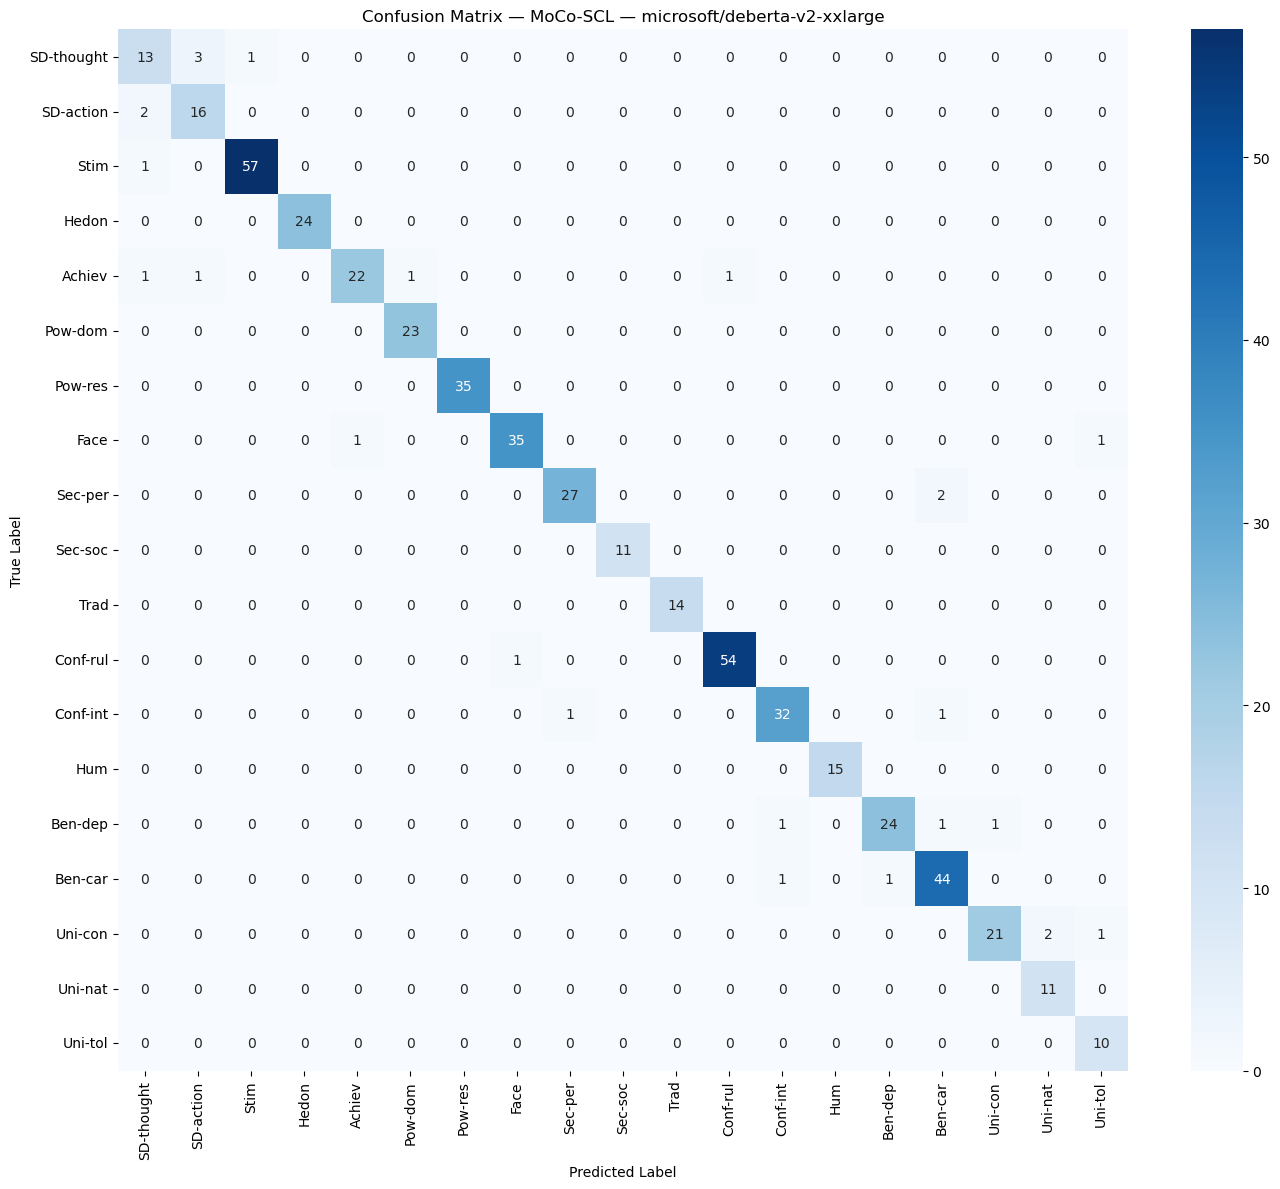

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/confusion_matrix.png


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results — DeBERTa-v2-XXLarge MoCo-SCL")
print("=" * 60)
print(classification_report(
    labels,
    preds,
    target_names=VALUE_LABELS,
    digits=4,
))

cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol",
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_labels,
    yticklabels=short_labels,
)
plt.title(f"Confusion Matrix — MoCo-SCL — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")


In [10]:
# The best macro-F1 model is saved during training by SaveBestMacroF1Callback.
# Do not save again here, otherwise the last epoch could overwrite the best epoch.
print(f"Best compact model directory: {BEST_MODEL_DIR}")
print("Expected files: config.json, tokenizer files, query_encoder_lora/, heads.pt, best_metric.json")


Best compact model directory: /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_moco_scl/best_macro_f1_model
Expected files: config.json, tokenizer files, query_encoder_lora/, heads.pt, best_metric.json
